<a href="https://colab.research.google.com/github/yibesh/-2025_Artifical-Intelligence-/blob/main/Iris_classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import numpy as np #for matrix multiplication
%matplotlib inline

# Load the Dataset

In [ ]:
df=pd.read_csv("IRIS.csv")



In [ ]:
##load from the online source
#import pandas as pd
#from sklearn.datasets import load_iris
#iris = load_iris()

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Let's have a look on the shape of the dataset:

In [ ]:
df.shape

(150, 5)

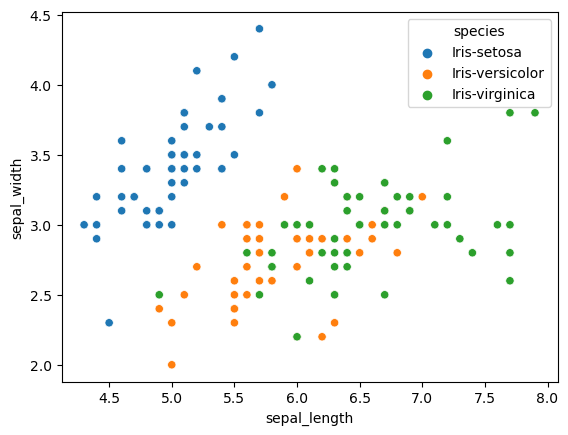

In [ ]:
sns.scatterplot(data=df, x="sepal_length", y="sepal_width",hue="species")
plt.show()

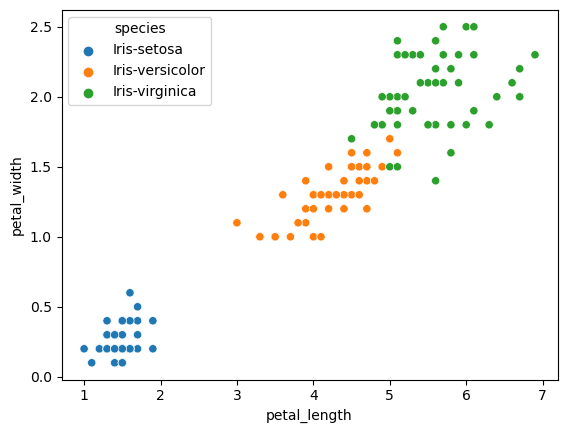

In [ ]:
sns.scatterplot(data=df, x="petal_length", y="petal_width",hue="species")
plt.show()

# Preprocess and Data Normalization

In [ ]:
df["species"]=df["species"].replace({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2})
label_name=["Iris-setosa","Iris-versicolor","Iris-virginica"]

# Split the training and target data


In [ ]:
#Lets make X and y in our Data:
X=df.drop(columns="species",axis=1)  #Training data
y=df["species"]   #target data

In [ ]:
y.shape

(150,)

In [ ]:
scaler=MinMaxScaler()
X=scaler.fit_transform(X)

# Train_test_split the Data:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
len(X_train)

120

In [ ]:
len(X_test)

30

# Call, Train and Predict the Model:

# KNN Model

In [ ]:
# Fitting clasifier to the Training set
# Loading libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score



In [ ]:
# Instantiate learning model (k = 3)
classifier = KNeighborsClassifier(n_neighbors=3)



In [ ]:
# Fitting the model
classifier.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

# Predicting the Test set results

In [ ]:
# Predicting the Test set results
pred1 = classifier.predict(X_test)
print(pred1)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# The Actual (true) value

In [ ]:
print(y_test)

73     1
18     0
118    2
78     1
76     1
31     0
64     1
141    2
68     1
82     1
110    2
12     0
36     0
9      0
19     0
56     1
104    2
69     1
55     1
132    2
29     0
127    2
26     0
128    2
131    2
145    2
108    2
143    2
45     0
30     0
Name: species, dtype: int64


# Evaluating KNN prediction Model

In [ ]:
# Evaluating KNN prediction Model

accuracy = accuracy_score(y_test, pred1)
print('Accuracy of our KNN model is equal ',  accuracy)

Accuracy of our KNN model is equal  1.0


# Confusion Matrix

In [ ]:
#cf=confusion_matrix(y_test,pred1)
#sns.heatmap(cf,annot=True,fmt="d",cmap="hot",xticklabels=label_name,yticklabels=label_name)
#plt.title('Confusion Matrix')
#plt.xlabel('Predicted labels')
#plt.ylabel('True labels')
#plt.show()

# Classification Report

In [ ]:
print(classification_report(y_test,pred1,target_names=label_name))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

